Raw shape: (1465, 16)
product_id              object
product_name            object
category                object
discounted_price       float64
actual_price            object
discount_percentage    float64
rating                  object
rating_count            object
about_product           object
user_id                 object
user_name               object
review_id               object
review_title            object
review_content          object
img_link                object
product_link            object
dtype: object
   product_id                                       product_name  \
0  B07JW9H4J1  Wayona Nylon Braided USB to Lightning Fast Cha...   
1  B098NS6PVG  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...   
2  B096MSW6CT  Sounce Fast Phone Charging Cable & Data Sync U...   

                                            category  discounted_price  \
0  Computers&Accessories|Accessories&Peripherals|...             399.0   
1  Computers&Accessories|Accessories&Peripheral

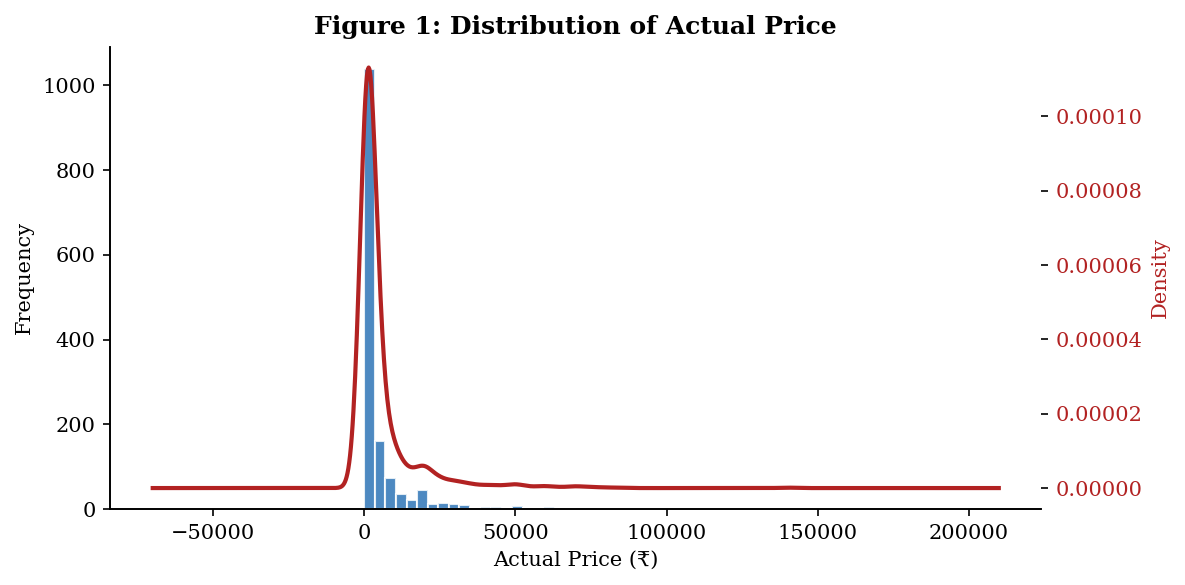

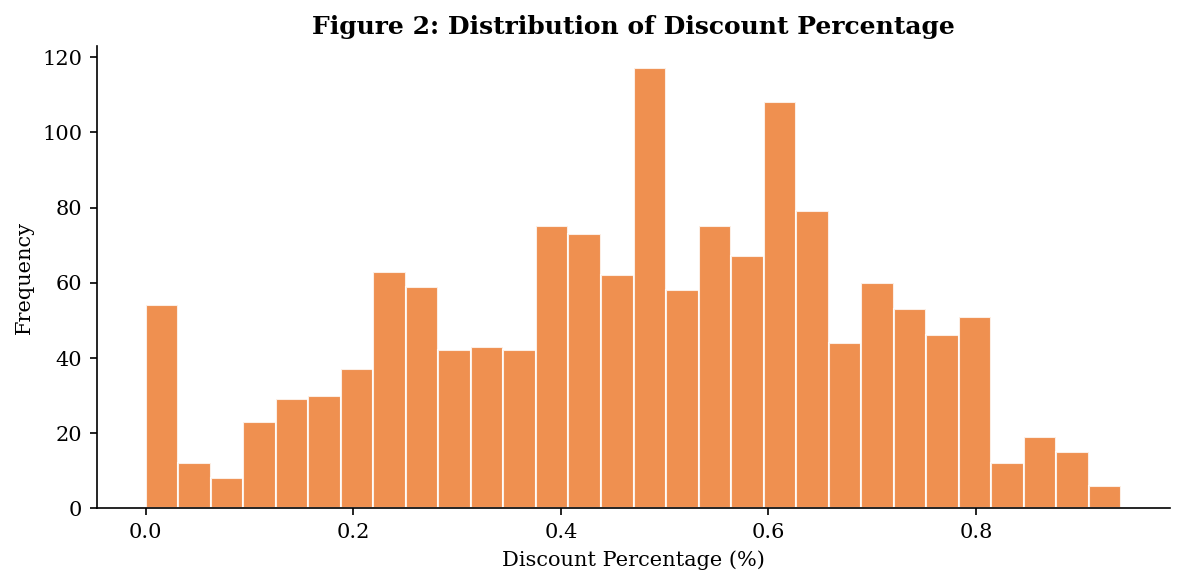

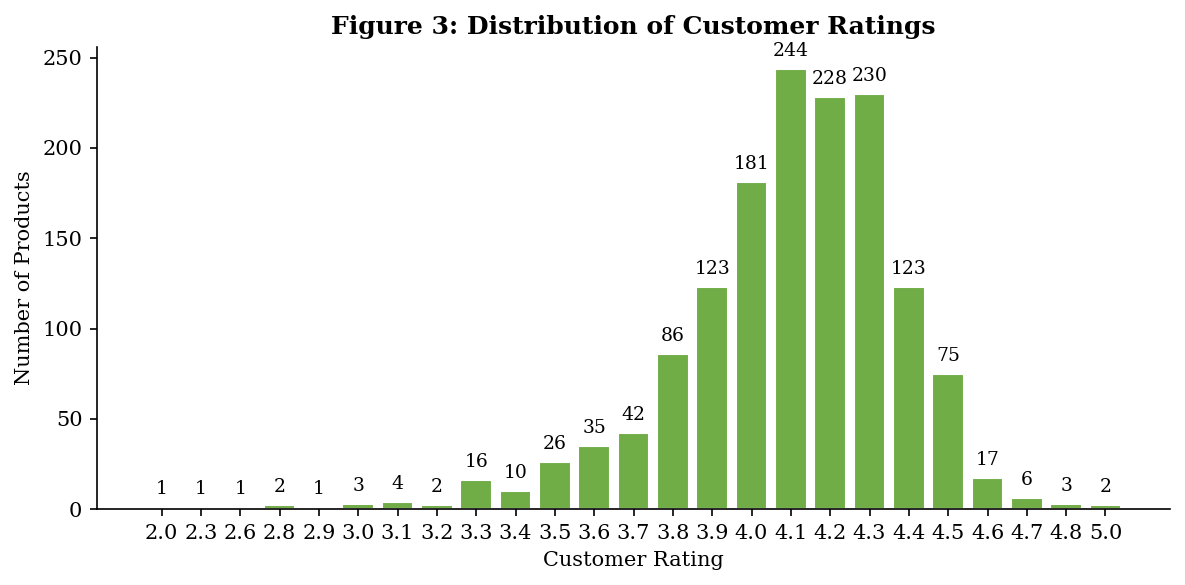

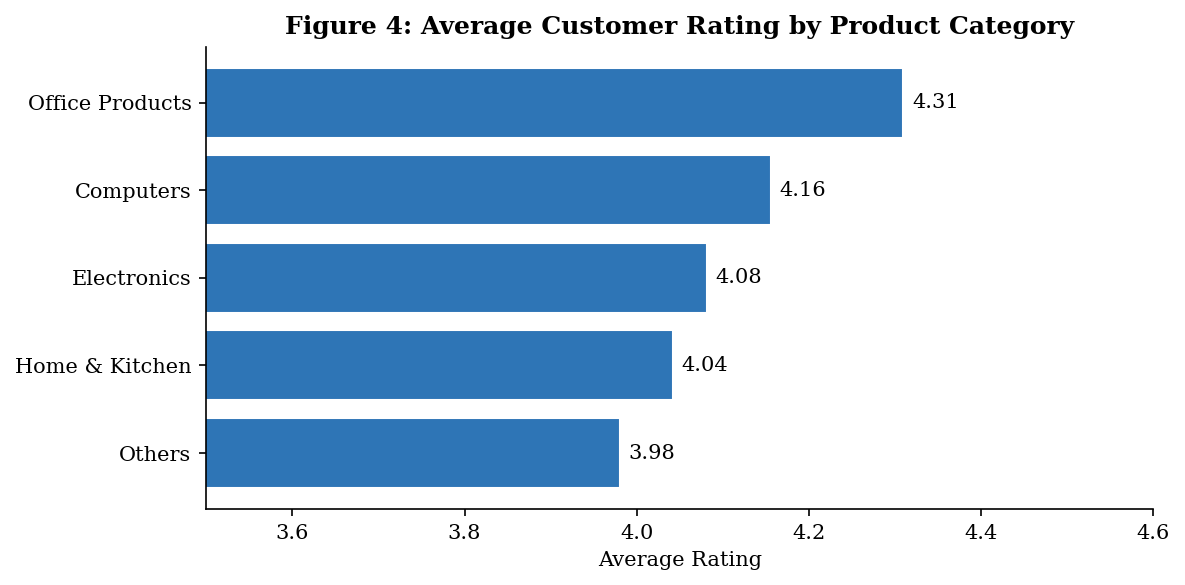

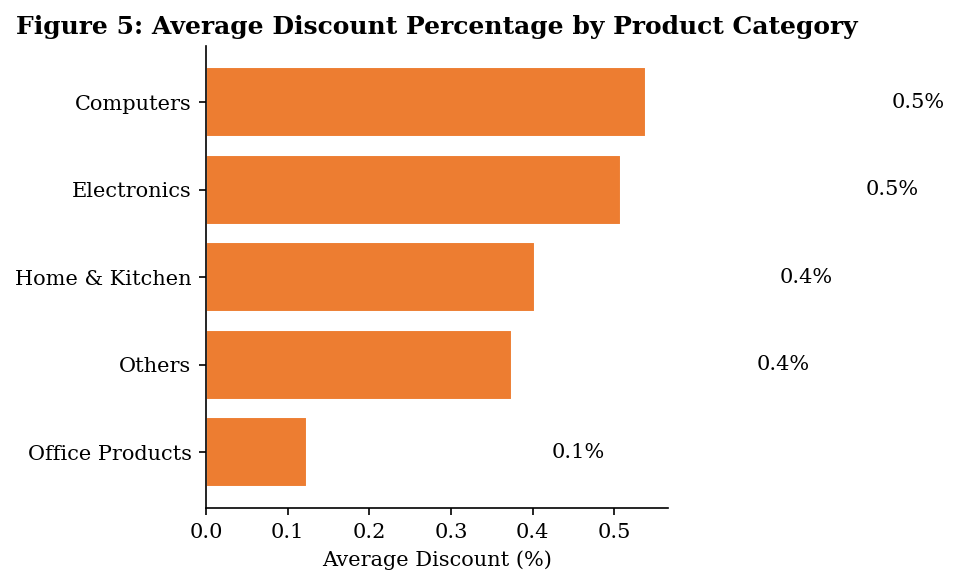

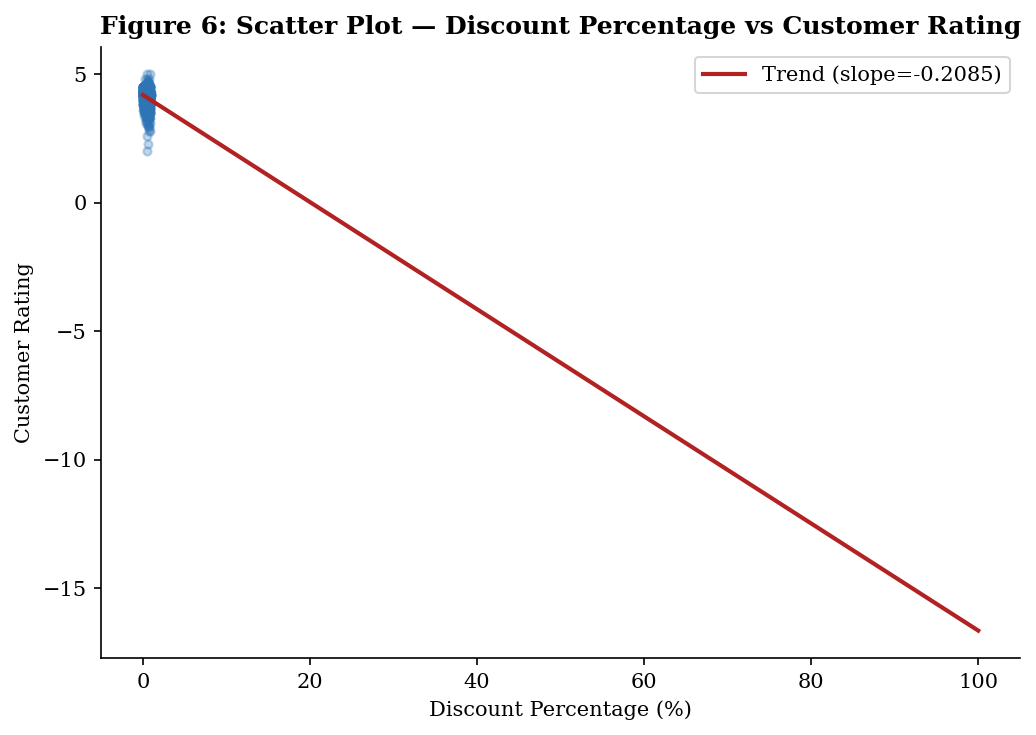

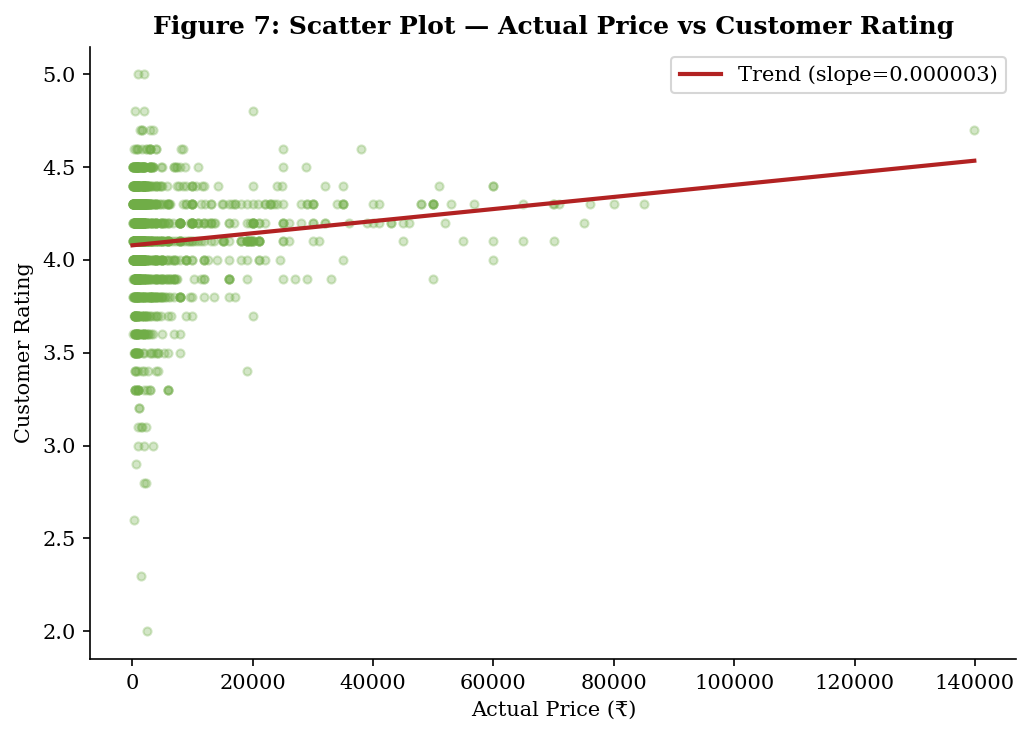

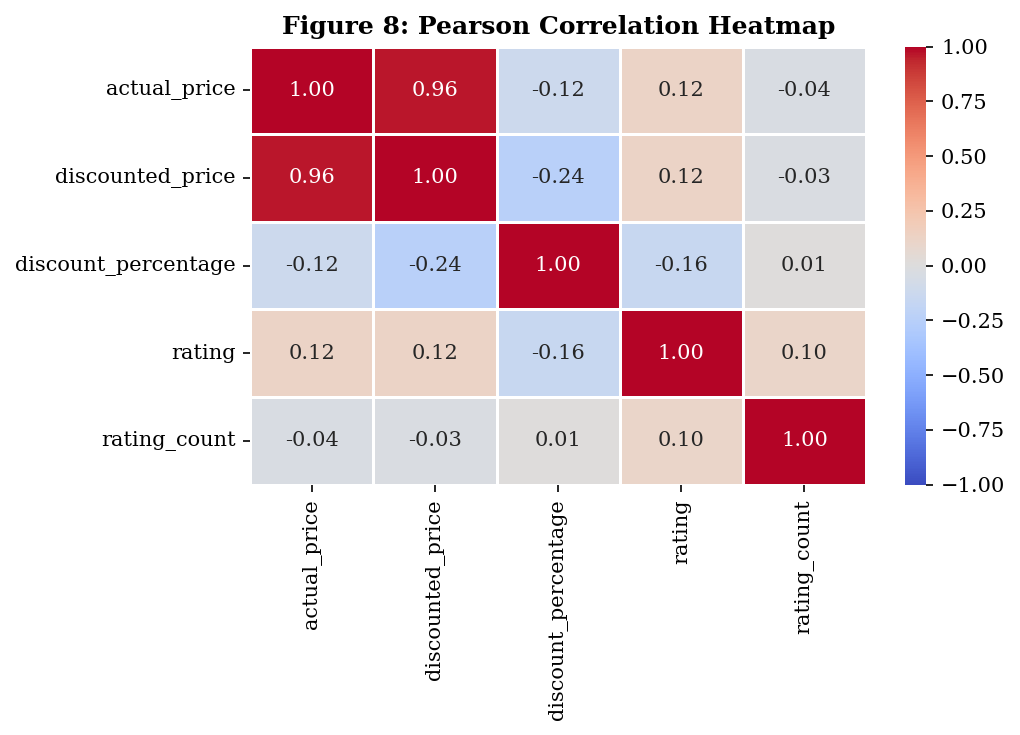

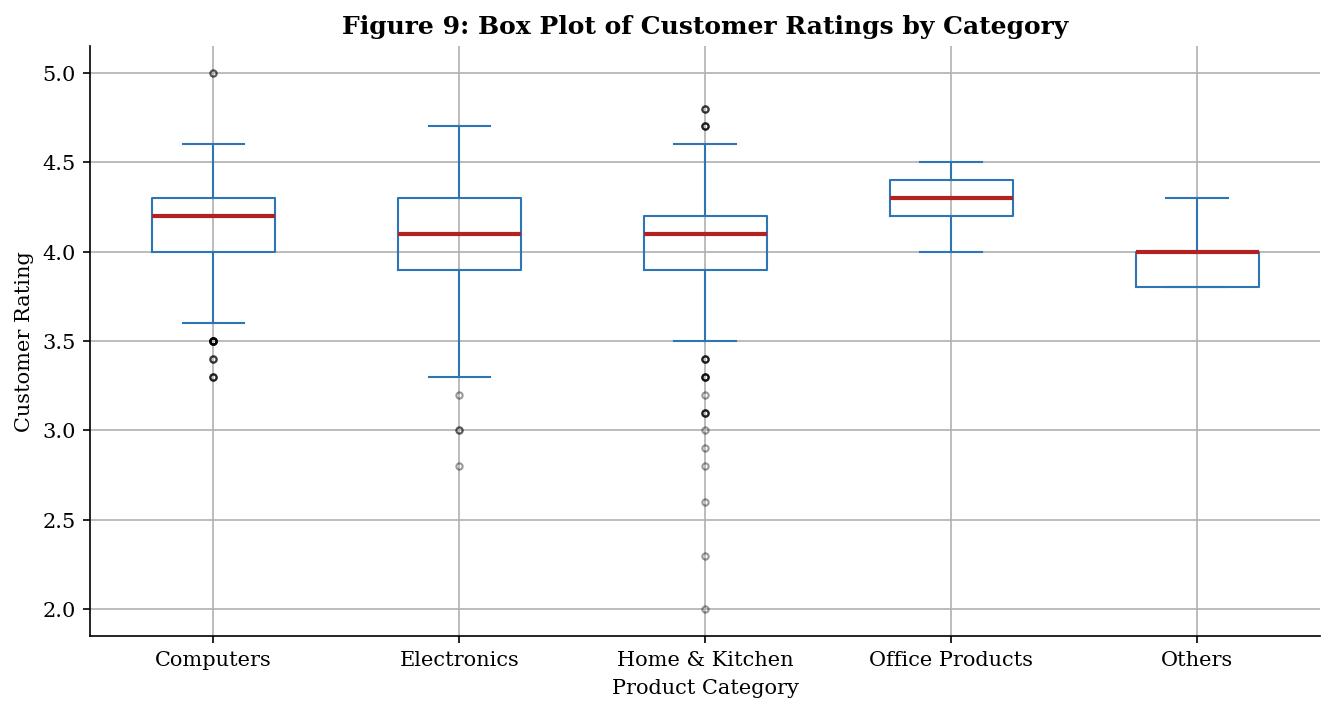

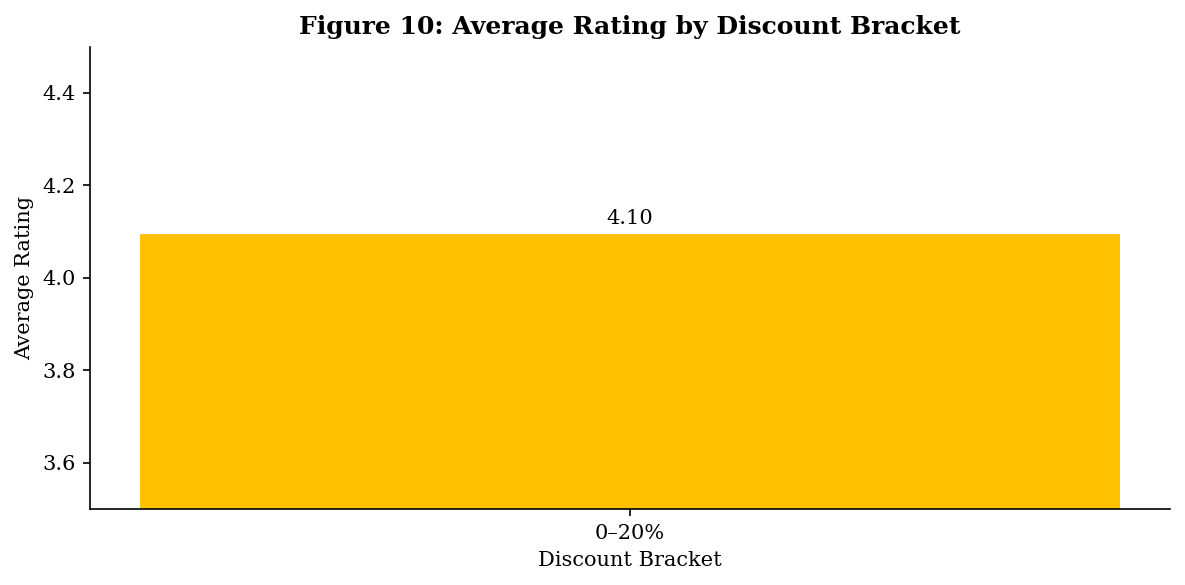


OBJECTIVE 1: Correlation Analysis

Pearson r (actual_price vs discount_percentage): r = -0.1179, p = 6.2358e-06
Pearson r (discount_percentage vs rating):       r = -0.1557, p = 2.1774e-09
Pearson r (actual_price vs rating):              r = 0.1225, p = 2.6484e-06

Spearman rho (actual_price vs discount_percentage): rho = -0.0651, p = 1.2828e-02
Spearman rho (discount_percentage vs rating):       rho = -0.1462, p = 1.9623e-08
Spearman rho (actual_price vs rating):              rho = 0.0336, p = 1.9976e-01

OBJECTIVE 2: One-Way ANOVA (Rating across Categories)

ANOVA: F = 13.9619, p = 3.5076e-11
→ Statistically significant difference in ratings across categories (p < 0.05)

Group means:
                 count   mean    std
broad_category                      
Computers          451  4.156  0.253
Electronics        526  4.082  0.270
Home & Kitchen     449  4.042  0.335
Office Products     31  4.310  0.149
Others               5  3.980  0.205

Pairwise t-tests (Bonferroni correction):
  

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr,spearmanr,f_oneway,linregress
PALETTE = ["#4C78A8", "#F58518", "#54A24B", "#B279A2"]

#Data Importing:
df_raw = pd.read_excel("/content/data_bdm_project.xlsx")
print("Raw shape:", df_raw.shape)
print(df_raw.dtypes)
print(df_raw.head(3))

#Data Cleaning:
df = df_raw.copy()

for col in ["actual_price", "discounted_price"]:
    df[col] = (df[col]
               .astype(str)
               .str.replace("₹", "", regex=False)
               .str.replace(",", "", regex=False)
               .str.strip())
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["discount_percentage"] = (df["discount_percentage"]
                              .astype(str)
                              .str.replace("%", "", regex=False)
                              .str.strip())
df["discount_percentage"] = pd.to_numeric(df["discount_percentage"], errors="coerce")

df["rating"] = pd.to_numeric(df["rating"].astype(str).str.strip(), errors="coerce")
df["rating_count"] = (df["rating_count"]
                      .astype(str)
                      .str.replace(",", "", regex=False)
                      .str.strip())
df["rating_count"] = pd.to_numeric(df["rating_count"], errors="coerce")

df["discount_pct_calc"] = np.where(
    df["actual_price"] > 0,
    (df["actual_price"] - df["discounted_price"]) / df["actual_price"] * 100,
    np.nan
)

def broad_cat(s):
    s = str(s).split("|")[0].strip()
    if "Computers" in s or "Computer" in s:
        return "Computers"
    elif "Electronics" in s or "Electronic" in s:
        return "Electronics"
    elif "Home" in s or "Kitchen" in s or "Appliances" in s:
        return "Home & Kitchen"
    elif "Office" in s:
        return "Office Products"
    else:
        return "Others"

df["broad_category"] = df["category"].apply(broad_cat)

df_clean = df.dropna(subset=["actual_price", "discounted_price", "discount_percentage", "rating"]).copy()
df_clean = df_clean[df_clean["rating_count"] > 0].copy()
df_clean = df_clean[df_clean["actual_price"] > 0].copy()
df_clean = df_clean.reset_index(drop=True)

print(f"\nCleaned shape: {df_clean.shape}")
print(df_clean["broad_category"].value_counts())

#Descriptive Statistics:
num_cols = ["actual_price", "discounted_price", "discount_percentage", "rating", "rating_count"]
desc = df_clean[num_cols].describe().T
desc["median"] = df_clean[num_cols].median()
desc["mode"]   = df_clean[num_cols].mode().iloc[0]
desc["skew"]   = df_clean[num_cols].skew()
print("\n=== Descriptive Statistics ===")
print(desc.round(2).to_string())

cat_desc = df_clean.groupby("broad_category")[["actual_price","discounted_price","discount_percentage","rating"]].agg(["mean","median","std"])
print("\n=== Category-wise Descriptive Statistics ===")
print(cat_desc.round(2).to_string())

#EDA Visualizations:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_clean["actual_price"], bins=40, color=PALETTE[0], edgecolor="white", alpha=0.85)
ax2 = ax.twinx()
df_clean["actual_price"].plot.kde(ax=ax2, color="firebrick", lw=2)
ax2.set_ylabel("Density", color="firebrick")
ax2.tick_params(axis="y", labelcolor="firebrick")
ax.set_xlabel("Actual Price (₹)")
ax.set_ylabel("Frequency")
ax.set_title("Figure 1: Distribution of Actual Price", fontweight="bold")
plt.tight_layout()
plt.savefig("fig1_price_distribution.png")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_clean["discount_percentage"], bins=30, color=PALETTE[1], edgecolor="white", alpha=0.85)
ax.set_xlabel("Discount Percentage (%)")
ax.set_ylabel("Frequency")
ax.set_title("Figure 2: Distribution of Discount Percentage", fontweight="bold")
plt.tight_layout()
plt.savefig("fig2_discount_distribution.png")
plt.show()

rating_counts = df_clean["rating"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(rating_counts.index.astype(str), rating_counts.values, color=PALETTE[2], edgecolor="white")
ax.set_xlabel("Customer Rating")
ax.set_ylabel("Number of Products")
ax.set_title("Figure 3: Distribution of Customer Ratings", fontweight="bold")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(int(bar.get_height())),
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("fig3_rating_distribution.png")
plt.show()

cat_rating = df_clean.groupby("broad_category")["rating"].mean().sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(cat_rating.index, cat_rating.values, color=PALETTE[0], edgecolor="white")
ax.set_xlabel("Average Rating")
ax.set_title("Figure 4: Average Customer Rating by Product Category", fontweight="bold")
ax.set_xlim(3.5, 4.6)
for bar, val in zip(bars, cat_rating.values):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f"{val:.2f}",
            va="center", fontsize=10)
plt.tight_layout()
plt.savefig("fig4_avg_rating_by_category.png")
plt.show()

cat_disc = df_clean.groupby("broad_category")["discount_percentage"].mean().sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(cat_disc.index, cat_disc.values, color=PALETTE[1], edgecolor="white")
ax.set_xlabel("Average Discount (%)")
ax.set_title("Figure 5: Average Discount Percentage by Product Category", fontweight="bold")
for bar, val in zip(bars, cat_disc.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, f"{val:.1f}%",
            va="center", fontsize=10)
plt.tight_layout()
plt.savefig("fig5_avg_discount_by_category.png")
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df_clean["discount_percentage"], df_clean["rating"],
           alpha=0.3, s=15, color=PALETTE[0])
m, b = np.polyfit(df_clean["discount_percentage"].dropna(), df_clean["rating"].dropna(), 1)
x_line = np.linspace(0, 100, 200)
ax.plot(x_line, m * x_line + b, color="firebrick", lw=2, label=f"Trend (slope={m:.4f})")
ax.set_xlabel("Discount Percentage (%)")
ax.set_ylabel("Customer Rating")
ax.set_title("Figure 6: Scatter Plot — Discount Percentage vs Customer Rating", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("fig6_scatter_discount_vs_rating.png")
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df_clean["actual_price"], df_clean["rating"],
           alpha=0.3, s=15, color=PALETTE[2])
m2, b2 = np.polyfit(df_clean["actual_price"].dropna(), df_clean["rating"].dropna(), 1)
x_line2 = np.linspace(df_clean["actual_price"].min(), df_clean["actual_price"].max(), 200)
ax.plot(x_line2, m2 * x_line2 + b2, color="firebrick", lw=2, label=f"Trend (slope={m2:.6f})")
ax.set_xlabel("Actual Price (₹)")
ax.set_ylabel("Customer Rating")
ax.set_title("Figure 7: Scatter Plot — Actual Price vs Customer Rating", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("fig7_scatter_price_vs_rating.png")
plt.show()

corr_df = df_clean[["actual_price", "discounted_price", "discount_percentage", "rating", "rating_count"]].corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title("Figure 8: Pearson Correlation Heatmap", fontweight="bold")
plt.tight_layout()
plt.savefig("fig8_correlation_heatmap.png")
plt.show()

order = df_clean.groupby("broad_category")["rating"].median().sort_values().index.tolist()
fig, ax = plt.subplots(figsize=(9, 5))
df_clean.boxplot(column="rating", by="broad_category", ax=ax,
                 boxprops=dict(color=PALETTE[0]),
                 medianprops=dict(color="firebrick", lw=2),
                 whiskerprops=dict(color=PALETTE[0]),
                 capprops=dict(color=PALETTE[0]),
                 flierprops=dict(marker="o", markersize=3, alpha=0.4))
ax.set_title("Figure 9: Box Plot of Customer Ratings by Category", fontweight="bold")
plt.suptitle("")
ax.set_xlabel("Product Category")
ax.set_ylabel("Customer Rating")
plt.tight_layout()
plt.savefig("fig9_boxplot_rating_by_category.png")
plt.show()

bins   = [0, 20, 40, 60, 80, 100]
labels = ["0–20%", "21–40%", "41–60%", "61–80%", "81–100%"]
df_clean["disc_bracket"] = pd.cut(df_clean["discount_percentage"], bins=bins, labels=labels, include_lowest=True)
bracket_rating = df_clean.groupby("disc_bracket")["rating"].mean()
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(bracket_rating.index.astype(str), bracket_rating.values, color=PALETTE[3], edgecolor="white")
ax.set_xlabel("Discount Bracket")
ax.set_ylabel("Average Rating")
ax.set_title("Figure 10: Average Rating by Discount Bracket", fontweight="bold")
ax.set_ylim(3.5, 4.5)
for bar, val in zip(bars, bracket_rating.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{val:.2f}",
            ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.savefig("fig10_avg_rating_by_discount_bracket.png")
plt.show()

#Statistical Analysis
print("\n" + "="*60)
print("OBJECTIVE 1: Correlation Analysis")
print("="*60)

x_ = df_clean.dropna(subset=["actual_price","discount_percentage"])
r1, p1 = pearsonr(x_["actual_price"], x_["discount_percentage"])
print(f"\nPearson r (actual_price vs discount_percentage): r = {r1:.4f}, p = {p1:.4e}")

y_ = df_clean.dropna(subset=["discount_percentage","rating"])
r2, p2 = pearsonr(y_["discount_percentage"], y_["rating"])
print(f"Pearson r (discount_percentage vs rating):       r = {r2:.4f}, p = {p2:.4e}")

z_ = df_clean.dropna(subset=["actual_price","rating"])
r3, p3 = pearsonr(z_["actual_price"], z_["rating"])
print(f"Pearson r (actual_price vs rating):              r = {r3:.4f}, p = {p3:.4e}")

sr1, sp1 = spearmanr(x_["actual_price"], x_["discount_percentage"])
sr2, sp2 = spearmanr(y_["discount_percentage"], y_["rating"])
sr3, sp3 = spearmanr(z_["actual_price"], z_["rating"])
print(f"\nSpearman rho (actual_price vs discount_percentage): rho = {sr1:.4f}, p = {sp1:.4e}")
print(f"Spearman rho (discount_percentage vs rating):       rho = {sr2:.4f}, p = {sp2:.4e}")
print(f"Spearman rho (actual_price vs rating):              rho = {sr3:.4f}, p = {sp3:.4e}")

print("\n" + "="*60)
print("OBJECTIVE 2: One-Way ANOVA (Rating across Categories)")
print("="*60)

groups = [group["rating"].dropna().values for _, group in df_clean.groupby("broad_category")]
F, p_anova = f_oneway(*groups)
print(f"\nANOVA: F = {F:.4f}, p = {p_anova:.4e}")
if p_anova < 0.05:
    print("→ Statistically significant difference in ratings across categories (p < 0.05)")
else:
    print("→ No significant difference detected")

print("\nGroup means:")
print(df_clean.groupby("broad_category")["rating"].agg(["count","mean","std"]).round(3).to_string())

print("\nPairwise t-tests (Bonferroni correction):")
cats = df_clean["broad_category"].unique()
pairs = []
for i in range(len(cats)):
    for j in range(i+1, len(cats)):
        g1 = df_clean[df_clean["broad_category"]==cats[i]]["rating"].dropna()
        g2 = df_clean[df_clean["broad_category"]==cats[j]]["rating"].dropna()
        t, p = stats.ttest_ind(g1, g2)
        pairs.append((cats[i], cats[j], round(t,3), round(p,4)))

n_tests = len(pairs)
for a, b, t, p in pairs:
    p_adj = min(p * n_tests, 1.0)
    sig = "**" if p_adj < 0.05 else "ns"
    print(f"  {a} vs {b}: t={t}, p_adj={p_adj:.4f} {sig}")

print("\n" + "="*60)
print("OBJECTIVE 3: Regression Analysis")
print("="*60)

y__ = df_clean.dropna(subset=["discount_percentage","rating"])
slope, intercept, r_val, p_val, se = linregress(y__["discount_percentage"], y__["rating"])
print(f"\nSimple Regression (discount_pct → rating):")
print(f"  slope={slope:.6f}, intercept={intercept:.4f}, R²={r_val**2:.4f}, p={p_val:.4e}")

X_cols = ["actual_price", "discount_percentage", "rating_count"]
sub = df_clean.dropna(subset=X_cols + ["rating"]).copy()
X = np.column_stack([np.ones(len(sub)), sub["actual_price"], sub["discount_percentage"], sub["rating_count"]])
y = sub["rating"].values
beta, residuals, rank, sv = np.linalg.lstsq(X, y, rcond=None)
y_pred = X @ beta
SS_res = np.sum((y - y_pred)**2)
SS_tot = np.sum((y - y.mean())**2)
R2 = 1 - SS_res/SS_tot
print(f"\nMultiple Regression (actual_price, discount_pct, rating_count → rating):")
print(f"  Intercept = {beta[0]:.4f}")
print(f"  actual_price coeff = {beta[1]:.6f}")
print(f"  discount_pct coeff = {beta[2]:.6f}")
print(f"  rating_count coeff = {beta[3]:.8f}")
print(f"  R² = {R2:.4f}")

print("\n" + "="*60)
print("ADDITIONAL: Discount Bracket vs Rating (ANOVA)")
print("="*60)

bracket_groups = [group["rating"].dropna().values for _, group in df_clean.groupby("disc_bracket")]
F_b, p_b = f_oneway(*bracket_groups)
print(f"ANOVA across discount brackets: F = {F_b:.4f}, p = {p_b:.4e}")
print(df_clean.groupby("disc_bracket")["rating"].agg(["count","mean"]).round(3).to_string())

summary_data = {
    "Metric": [
        "Total Products (cleaned)",
        "Mean Actual Price (₹)",
        "Median Actual Price (₹)",
        "Mean Discount %",
        "Median Discount %",
        "Mean Rating",
        "Mode of Rating",
        "Std Dev of Rating",
        "Pearson r (Price vs Discount%)",
        "Pearson r (Discount% vs Rating)",
        "Pearson r (Price vs Rating)",
        "ANOVA F-stat (Rating ~ Category)",
        "ANOVA p-value (Rating ~ Category)",
    ],
    "Value": [
        len(df_clean),
        round(df_clean["actual_price"].mean(), 2),
        round(df_clean["actual_price"].median(), 2),
        round(df_clean["discount_percentage"].mean(), 2),
        round(df_clean["discount_percentage"].median(), 2),
        round(df_clean["rating"].mean(), 3),
        float(df_clean["rating"].mode().iloc[0]),
        round(df_clean["rating"].std(), 3),
        round(r1, 4),
        round(r2, 4),
        round(r3, 4),
        round(F, 4),
        f"{p_anova:.4e}",
    ]
}

summary_df = pd.DataFrame(summary_data)

print("\n=== FINAL SUMMARY TABLE ===")
print(summary_df.to_string(index=False))

summary_df.to_csv("analysis_summary.csv", index=False)
print("Summary: analysis_summary.csv")
